In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [4]:
from sctram.infer._paga import PAGAInference
from sctram.evaluate._adjacency import AdjacencyMatrixEvaluation
from sctram.input import read_dict

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

2025-02-24 13:08:12.446 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/Users/kemalinecik/git_nosync/sctram/__temp__/data/norman_sciplex_cpa.h5ad') already exists. Skipping download.


# Input

In [7]:
ground_truth_trajectories = {
    "trajectory_1": [
        ('Vehicle_1.0', 'BMS_0.001'),
        ('BMS_0.001', 'BMS_0.005'),
        ('BMS_0.005', 'BMS_0.01'),
        ('BMS_0.01', 'BMS_0.05'),
        ('BMS_0.05', 'BMS_0.1'),
        ('BMS_0.1', 'BMS_0.5'),
        ('BMS_0.5', 'BMS_1.0'),
    ],
}
input_trajectories_all = read_dict(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("trajectory_1", include_additional_nodes=False)

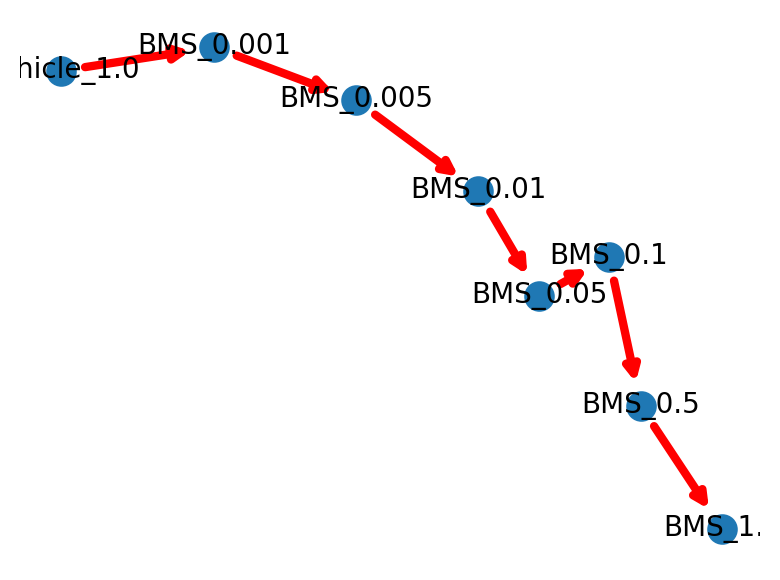

In [8]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

# PAGA

In [9]:
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
paga_inference = PAGAInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90}, 
    adata=adata, 
    labels=adata.obs["drug_dose_name"]
)
paga_inference.calculate()
# the same operation in the `infer` example notebook.

2025-02-24 13:08:12.881 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:161 - Initializing from AnnData without precomputed neighbors.
2025-02-24 13:08:12.882 | DEBUG    | sctram.infer._base:_add_labels_to_adata:220 - Adding provided labels to AnnData object.
2025-02-24 13:08:12.882 | INFO     | sctram.infer._base:_initialize_from_adata_without_neighbors:168 - No precomputed neighbors found in AnnData.
2025-02-24 13:08:12.883 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:172 - AnnData initialized successfully from AnnData without neighbors.
2025-02-24 13:08:12.883 | INFO     | sctram.infer._base:calculate:496 - Starting PAGAInference trajectory inference.
2025-02-24 13:08:12.883 | INFO     | sctram.infer._base:calculate:499 - Performing trajectory inference.
2025-02-24 13:08:12.883 | INFO     | sctram.infer._base:_needs_neighbors:514 - Computing neighbors.
2025-02-24 13:08:12.884 | INFO     | sctram.utils._loguru_scanpy_capture:emit:5

In [10]:
inferred_trajectories = paga_inference.get_result("adjacency")
inferred_trajectories_labels = paga_inference.get_result("labels")

In [11]:
adjacency_evaluation = AdjacencyMatrixEvaluation(
    method_params = dict(
        metrics = [
            "frobenius",
            "l1_norm",
            "accuracy",
            "graph_edit_distance",
            "spectral_distance",
            "jaccard_similarity",
            "hamming_distance",
            "precision",
            "recall",
            "f1_score",
            "permutation_marginalized_ssim",
            "mantel_correlation",
            "average_shortest_path_difference",
            "laplacian_spectral_emd",
            "clustering_coeff_diff",
            "gdv_similarity",
            "weisfeiler_lehman_distance",
            "gin_gnn_similarity",
            "maximum_common_subgraph_distance",
            "random_walk_kernel_distance",
            "persistence_diagram_distance",
        ]
    )
)

2025-02-24 13:08:16.103 | DEBUG    | sctram.evaluate._adjacency:__init__:38 - Initialized AdjacencyMatrixEvaluation with metrics: ['frobenius', 'l1_norm', 'accuracy', 'graph_edit_distance', 'spectral_distance', 'jaccard_similarity', 'hamming_distance', 'precision', 'recall', 'f1_score', 'permutation_marginalized_ssim', 'mantel_correlation', 'average_shortest_path_difference', 'laplacian_spectral_emd', 'clustering_coeff_diff', 'gdv_similarity', 'weisfeiler_lehman_distance', 'gin_gnn_similarity', 'maximum_common_subgraph_distance', 'random_walk_kernel_distance', 'persistence_diagram_distance']


In [12]:
logging.getLogger().setLevel(logging.DEBUG)
try:
    adjacency_evaluation.evaluate(
        given_trajectory=input_trajectories,
        inferred_trajectory=inferred_trajectories,
        labels=inferred_trajectories_labels
    )
finally:
    logging.getLogger().setLevel(logging.INFO)

2025-02-24 13:08:16.172 | INFO     | sctram.evaluate._base:evaluate:159 - Starting evaluation with AdjacencyMatrixEvaluation.
2025-02-24 13:08:16.172 | DEBUG    | sctram.evaluate._base:evaluate:162 - Verifying given trajectory.
2025-02-24 13:08:16.173 | DEBUG    | sctram.evaluate._base:evaluate:165 - Verifying inferred trajectory.
2025-02-24 13:08:16.173 | DEBUG    | sctram.evaluate._base:evaluate:169 - Verifying labels.
2025-02-24 13:08:16.173 | DEBUG    | sctram.evaluate._adjacency:_verify_labels_data_specific:92 - Checking the consistency between the given graph and labels.
2025-02-24 13:08:16.174 | DEBUG    | sctram.evaluate._base:evaluate:175 - Preparing trajectories before subsetting.
2025-02-24 13:08:16.174 | DEBUG    | sctram.evaluate._adjacency:_prepare_before_subset:110 - Converting given trajectory to adjacency matrix.
2025-02-24 13:08:16.175 | DEBUG    | sctram.evaluate._adjacency:_prepare_before_subset:114 - Given adjacency matrix shape: (8, 8)
2025-02-24 13:08:16.175 | DE

In [13]:
adjacency_evaluation.get_result()

{'frobenius': 2.635131946587082,
 'l1_norm': 12.764002132770933,
 'accuracy': 0.84375,
 'graph_edit_distance': 5,
 'spectral_distance': 1.8115596591989842,
 'jaccard_similarity': 0.4444444444444444,
 'hamming_distance': 10,
 'precision': 0.6666666666666666,
 'recall': 0.5714285714285714,
 'f1_score': 0.6153846153846153,
 'permutation_marginalized_ssim': 0.562131478554275,
 'mantel_correlation': -0.12115482014264461,
 'average_shortest_path_difference': 2.8883310328816623,
 'laplacian_spectral_emd': 0.01695573848739305,
 'clustering_coeff_diff': 0.20624410133766674,
 'gdv_similarity': 0.8775299798415259,
 'weisfeiler_lehman_distance': 0.9009852457023337,
 'gin_gnn_similarity': 0.9961596131324768,
 'maximum_common_subgraph_distance': 5.0,
 'random_walk_kernel_distance': 0.39548393618631983,
 'persistence_diagram_distance': 11.507997350176314}

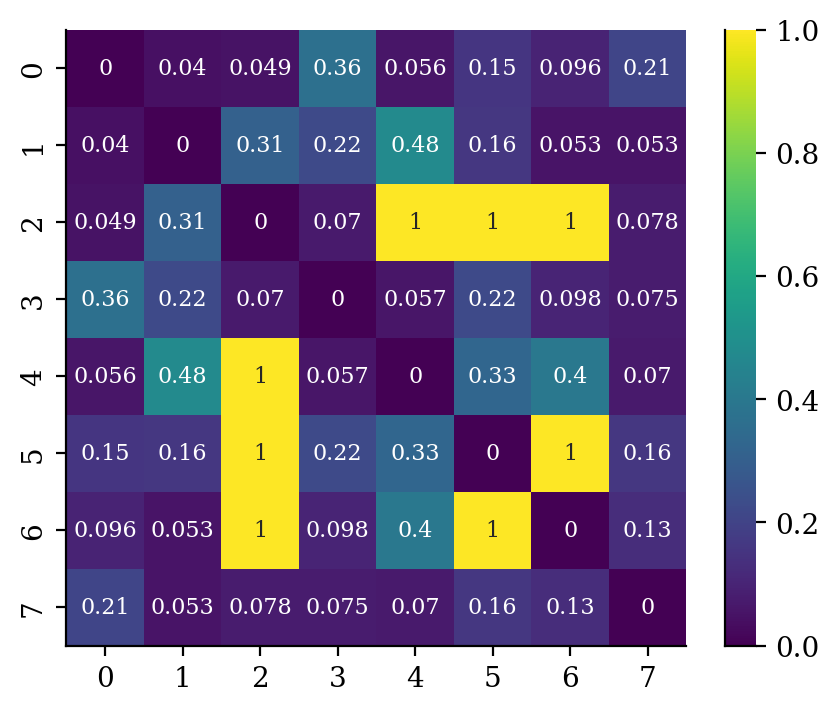

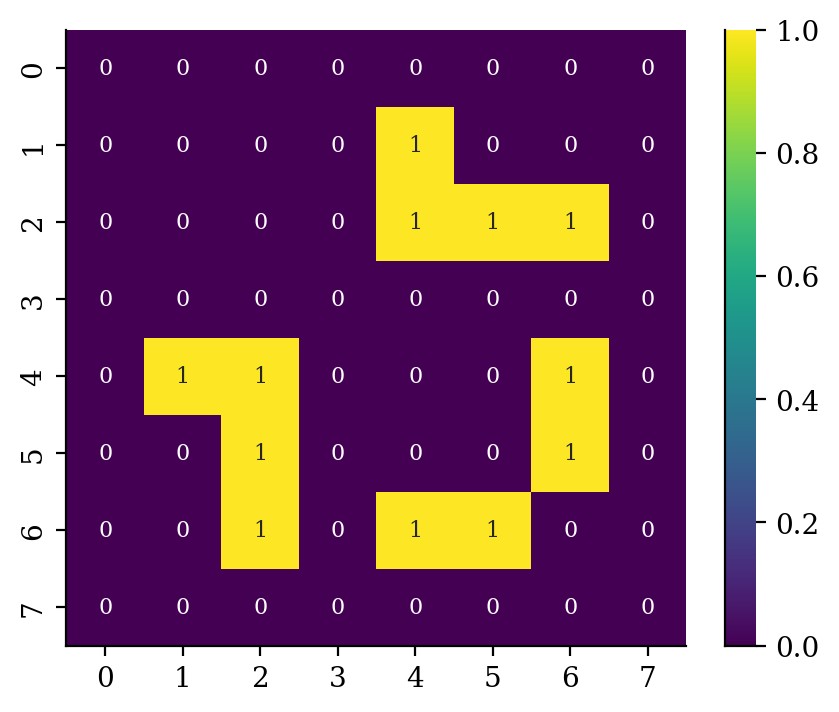

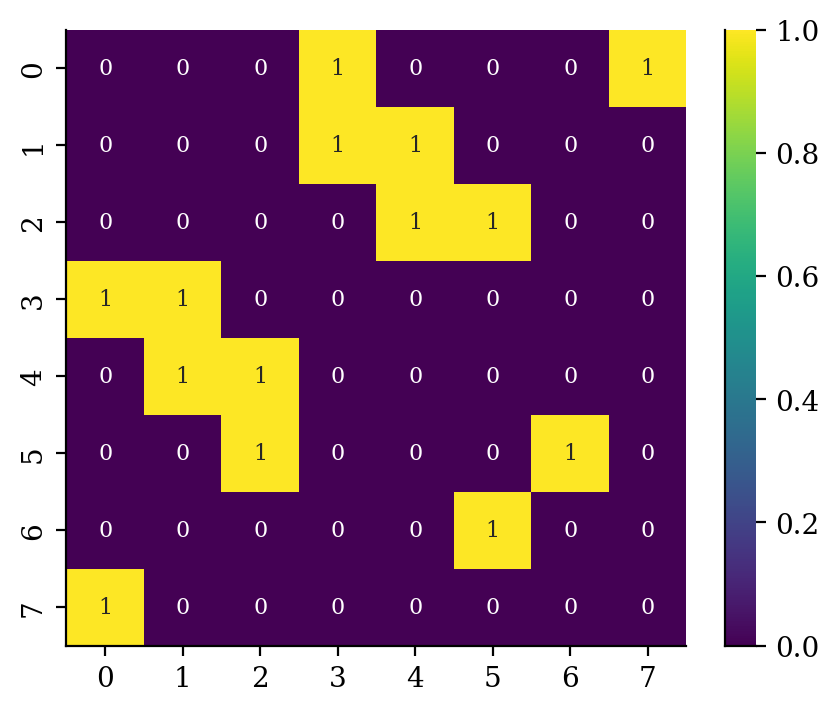

In [14]:
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_evaluation.prepared_after_subset_inferred, cmap='viridis', annot=True, annot_kws={"fontsize": 8})
sns.despine()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_evaluation.prepared_after_subset_inferred>0.4, cmap='viridis', annot=True, annot_kws={"fontsize": 8})
sns.despine()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_evaluation.prepared_after_subset_given, cmap='viridis', annot=True, annot_kws={"fontsize": 8})
sns.despine()
plt.show()